# Text classification :: Overview

## Task 

We want to build a Spam detector which, given examples of spam emails (e.g. flagged by users) and examples of regular (non-spam, also called "ham") emails, learns how to flag new unseen emails as spam or non-spam.

## Data

We will use the [SpamAssassin](https://spamassassin.apache.org/) public email corpus. This dataset contains ~6'000 labeled emails with a ~30% spam ratio. If you want to learn more about this dataset, check [this](https://spamassassin.apache.org/old/publiccorpus/). (*Note: Datasets of text are called corpora and samples are called documents.*) 

The dataset has been downloaded for you and is available in the *data* folder.

## Notebook overview

* Load the data
* Text preprocessing
* Data exploration
* Feature extraction
* Build a spam detector
* What did our model learn? Error analysis

# Text classification :: Spam detection


## Load the data

In [1]:
# Load libraries and helper functions
import tools

In [2]:
# Load the data
df = tools.load_data()

Data loaded.
Data size: (5832, 2)


Let's check the number of samples per class in the data.

Samples per class (%):
non-spam    70.3
spam        29.7
Name: proportion, dtype: float64




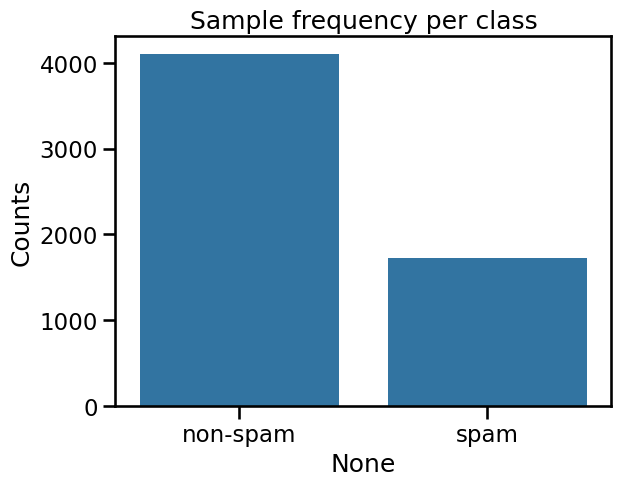

In [3]:
tools.plot_class_frequency(df)

Now, let's have a look at a few rows from the dataset.

***Note:*** The *label* is 0 for *non-spam* and 1 for *spam*.

In [4]:
# If you rerun this cell then you get a different set of samples displayed
df.sample(3)

,label,text
1729,1,"FROM=SEKO MOSHOOD MOBUTU Tel=234-1-776-2397 Dear Friend I am the first son of the late Mobutu Sese Seko, the former President of the Congo Republic. I am presently under protective custody in Nigeria as a political refugee. I got your contact over the internet during my search for a stranger that can cooperate with me in this mutual transaction.i took this option because my family friends and associates cpuld not be trusted any more since they contributed to my present predicament. I want you to note that this business will benefit both of us. However, you must confirm your ability to handle this because it involves a large amount of money. The money (50 million US DOLLARS is my share of my father's estate. I boxed and shipped the money to a security company abroad at the peak of the war/political crisis that rocked my country few years ago. Now the crisis has ended and I need a trustworthy person like you to proceed to the place of the security company in order to clear the fund and invest on my behalf as I dont want my name to be used for now. Note that I will send to you the relevant documents that will enable you take possesion of the the fund for onward investment for our mutual benefit. All I need from you is as follows: 1. A letter of committment (duely signed) that you will keep the transaction strictly confidential. 2. Your confirmation of your ability to handle this. 3. Your international identity or driving licence number for identification to the security company. 4. Your telephone and fax numbers for communication. 5. Your full permanent address. As soon as I get the above information from you, I will disclose to you the name and the country of the security company. I will forward your name and particulars to the security company to enable them contact you accordingly. I will also send to you a LETTER OF AUTHORITY to enable you clear the fund on my behalf. Note that this is a very safe transaction as this money is my share of my father'sestate. I am..."
3361,0,"> Yes, I think some others, (mgm?) have spamtrap data in there too. > My corpus is about 50% spamtrap spam at any given time. Let me know if I should leave that out next time, I do keep it separate. My spamtraps are pretty clean of viruses and bounce messages most of the time. -- Michael Moncur mgm at starlingtech.com http://www.starlingtech.com/ ""Lack of money is no obstacle. Lack of an idea is an obstacle."" --Ken Hakuta"
2281,0,"This is something new, or at least new to me: Politspam (n): Using a spam engine for political purposes. In this particular case, to get back at the University of Groningen. The content suggests its more prank than vigilante activism (in the old days we used to say ""someone left their terminal unguarded"") but what's interesting is that it's not trying to sell me anything or lead me to any for-fee service, it's just trying to spread a meme that RUG is evil. >>>>> ""w"" == wpin <lslifriend> writes: w> Those who want to leave for the Netherlands to carry on any w> kind of education,including for PHD, must be careful w> . Especially the university of Groningen(RUG) should be w> avoided. This university was once a good one but now it has w> lost its reputation. ... Studying is a good investment in time w> and money. So invest in the right place and time. You are w> warned. w> Sincerely yours, w> hyohxsycjlakdbmhjpiouupngoqrm Has anyone else started to receive either consumer vigilante or political activism messages via spam methods? -- Gary Lawrence Murphy - garym@teledyn.com - TeleDynamics Communications - blog: http://www.auracom.com/~teledyn - biz: http://teledyn.com/ - ""Computers are useless. They can only give you answers."" (Picasso)"


## Text preprocessing

Good text preprocessing is an essential part of every NLP project!

Our goal here is to build a model that distinguishes non-spam from spam. The idea here is to "clean" and "standardize" raw text before feeding it to our machine learning model. We need to keep as many "informative" words as possible, while discarding the "uniformative" ones. Removing unnecessary content, i.e. the "noise", from our texts will help to improve the accuracy of our models.

<div class="alert alert-success">
<h3>Questions</h3>
    
Take a few minutes to look at the raw text.
    
__Q1.__ Which parts of the text do you think should be removed to make it readable?
    
__Q2.__ How could the parts that we have just removed for text cleaning still be useful for the distinction of spam and non-spam?
</div>

### Answers

__Q1.__ Here are some suggestions of what could be removed or changed in order to clean the text:

* HTML tags 
* URLs
* E-mail addresses
* Punctuation marks, digits (e.g. 2002, 1.1, ...)
* Multiple whitespaces
* Case conversion (e.g. Dog vs dog, ...)
* English STOPWORDS (e.g. a, is, my, i, all, and, by...)
* ...

__Q2.__ The precise text within HTML tags, URLs, or email addresses will differ so much between our samples that it is unlikely to be helpful to distinguish spam from non-spam. However, the number of occurrences of HTML tags, URLs, etc. within a text might be useful for this distinction. Similarly, the length of the emails and the frequency of punctuation marks or upper case letters may also give us clues as to whether we are dealing with spam or not.


The *clean_corpus* function below will take care of the parts raised by Question 1.

For the ideas from Question 2 we will create new features and investigate their effects in the subsection **What about "spammish" signatures?**. 

In [5]:
df = tools.clean_corpus(df)

print("Data cleaned")

Data cleaned


Let's have a look at a few "cleaned" examples.

In [6]:
tools.show_clean_text(df)


Original document:

URL: http://boingboing.net/#85538898 Date: Not supplied [IMG:
http://boingboing.net/Images/luckystack1.jpg]Tim Biskup is an artist who does a lot of work for
animation studios. His work is inspired by one of my favorite illustrators, Jim Flora. Tim's selling
a deck of poker cards, each with a different illo, and they look terrific. Lots of whimsical
monsters and happy monkeys and weird prehistoric plants. I pre-ordered my deck just now. Hurry, only
2500 decks will be printed! Link[1] Discuss[2] [1]
http://www.timbiskup.com/timsite/timpages/luckystack.html [2]
http://www.quicktopic.com/17/H/6E5eribTLCzLD

Cleaned document:

date supplied biskup artist does work animation studios work inspired favorite illustrators flora
tims selling deck poker cards different illo look terrific lots whimsical monsters happy monkeys
weird prehistoric plants ordered deck just hurry decks printed link discuss


## Data Exploration :: What makes spam distinct?

### Frequent words

Which words distinguish spam from non-spam? Can we  identify the words in a text that are the most informative about its topic?

Let's find the 10 most frequent words in spam and non-spam and compare them.

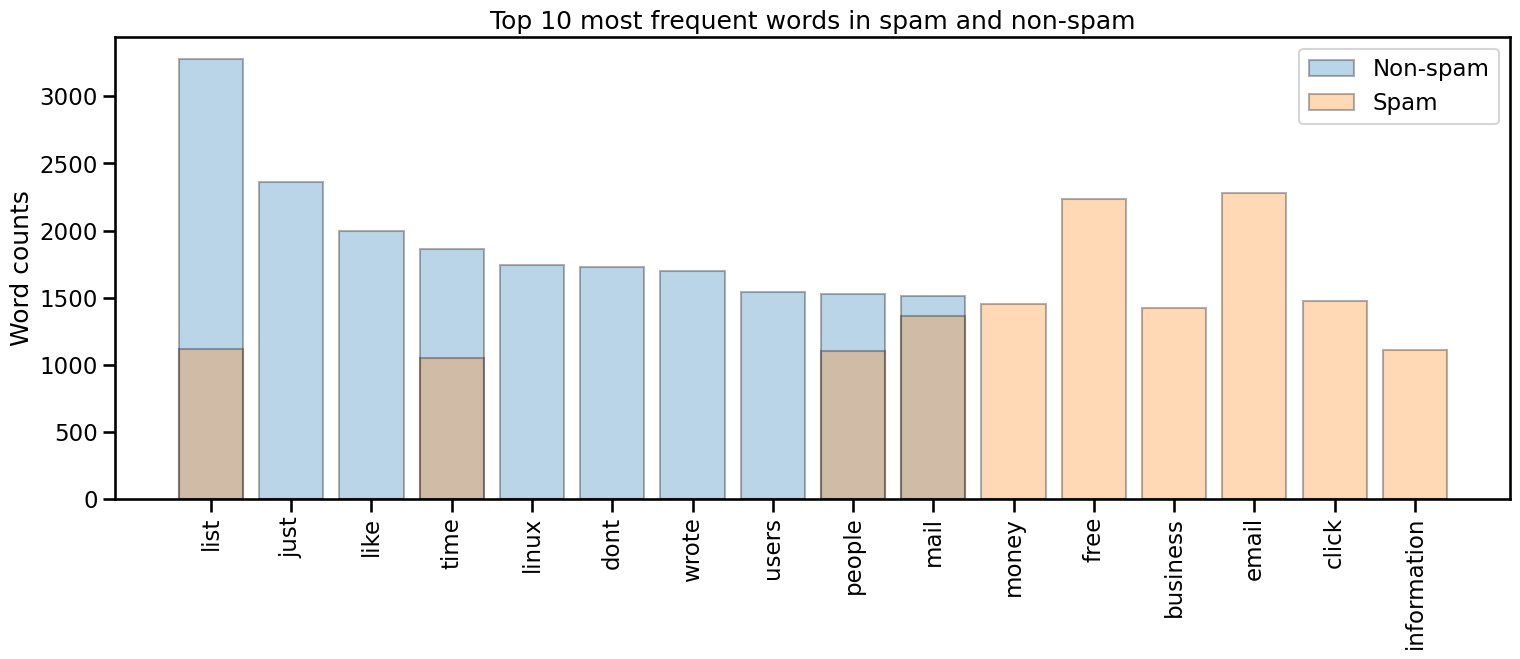

In [7]:
tools.plot_most_common_words(df=df, N=10)

<div class="alert alert-success">
<h3>Questions</h3>
    
__Q1.__ Which of the top 10 most frequent "spammish" words are unique to that class?

__Q2.__ Which of the top 10 most frequent "non-spammish" words are unique to that class?
     
__Q3.__ For the words that occur in both lists, which ones are likely still useful for distinguishing the classes?
    
__Q4.__ Which ones are likely not?
    
    
</div>

### Answers

__Q1.__ **Frequent "spammish" words**: 

* free
* email
* click
* business
* money

__Q2.__ **Frequent "non-spammish" words**:
* just
* like
* linux
* wrote
* users  

__Q3.__ **Occur in both top 10 but could be useful for distinctions**:
* list
* time

__Q4.__ **Occur in both top 10 but are unlikely to be useful**:
* people
* mail

<div class="alert alert-success">
<h3>Task 1</h3>
    
Change `N=10` to `N=30` and compare the outcome.
</div>

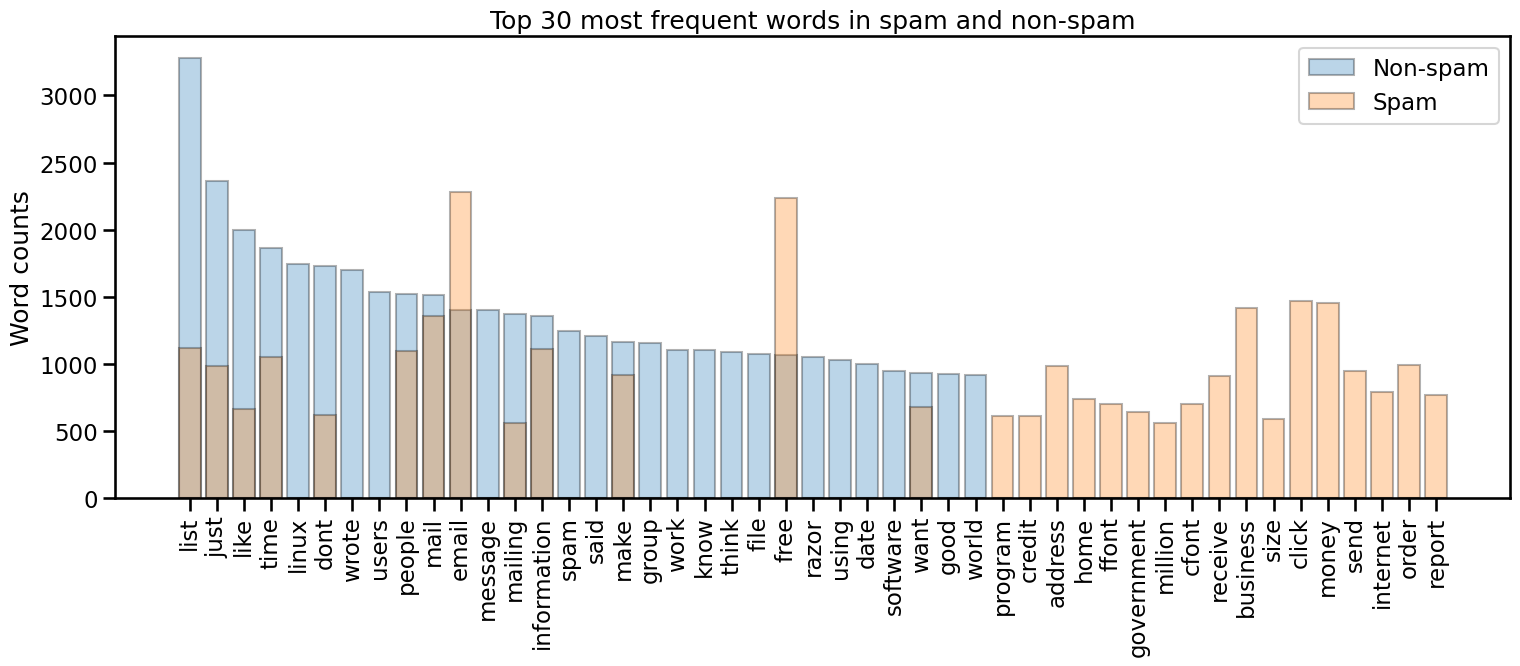

In [8]:
tools.plot_most_common_words(df=df, N=30)

### Observation

As we use more top words we get more overlap between the classes.  
However words like _email_ or _free_ are still mch more frequent in the **spam** class 

### What about "spammish" signatures?

* Do spams contain more HTML tags? 
* Does non-spam contain more URLs and E-mail adresses? 
* Are spams mails longer than non-spam? 
* ...

Let's find out!

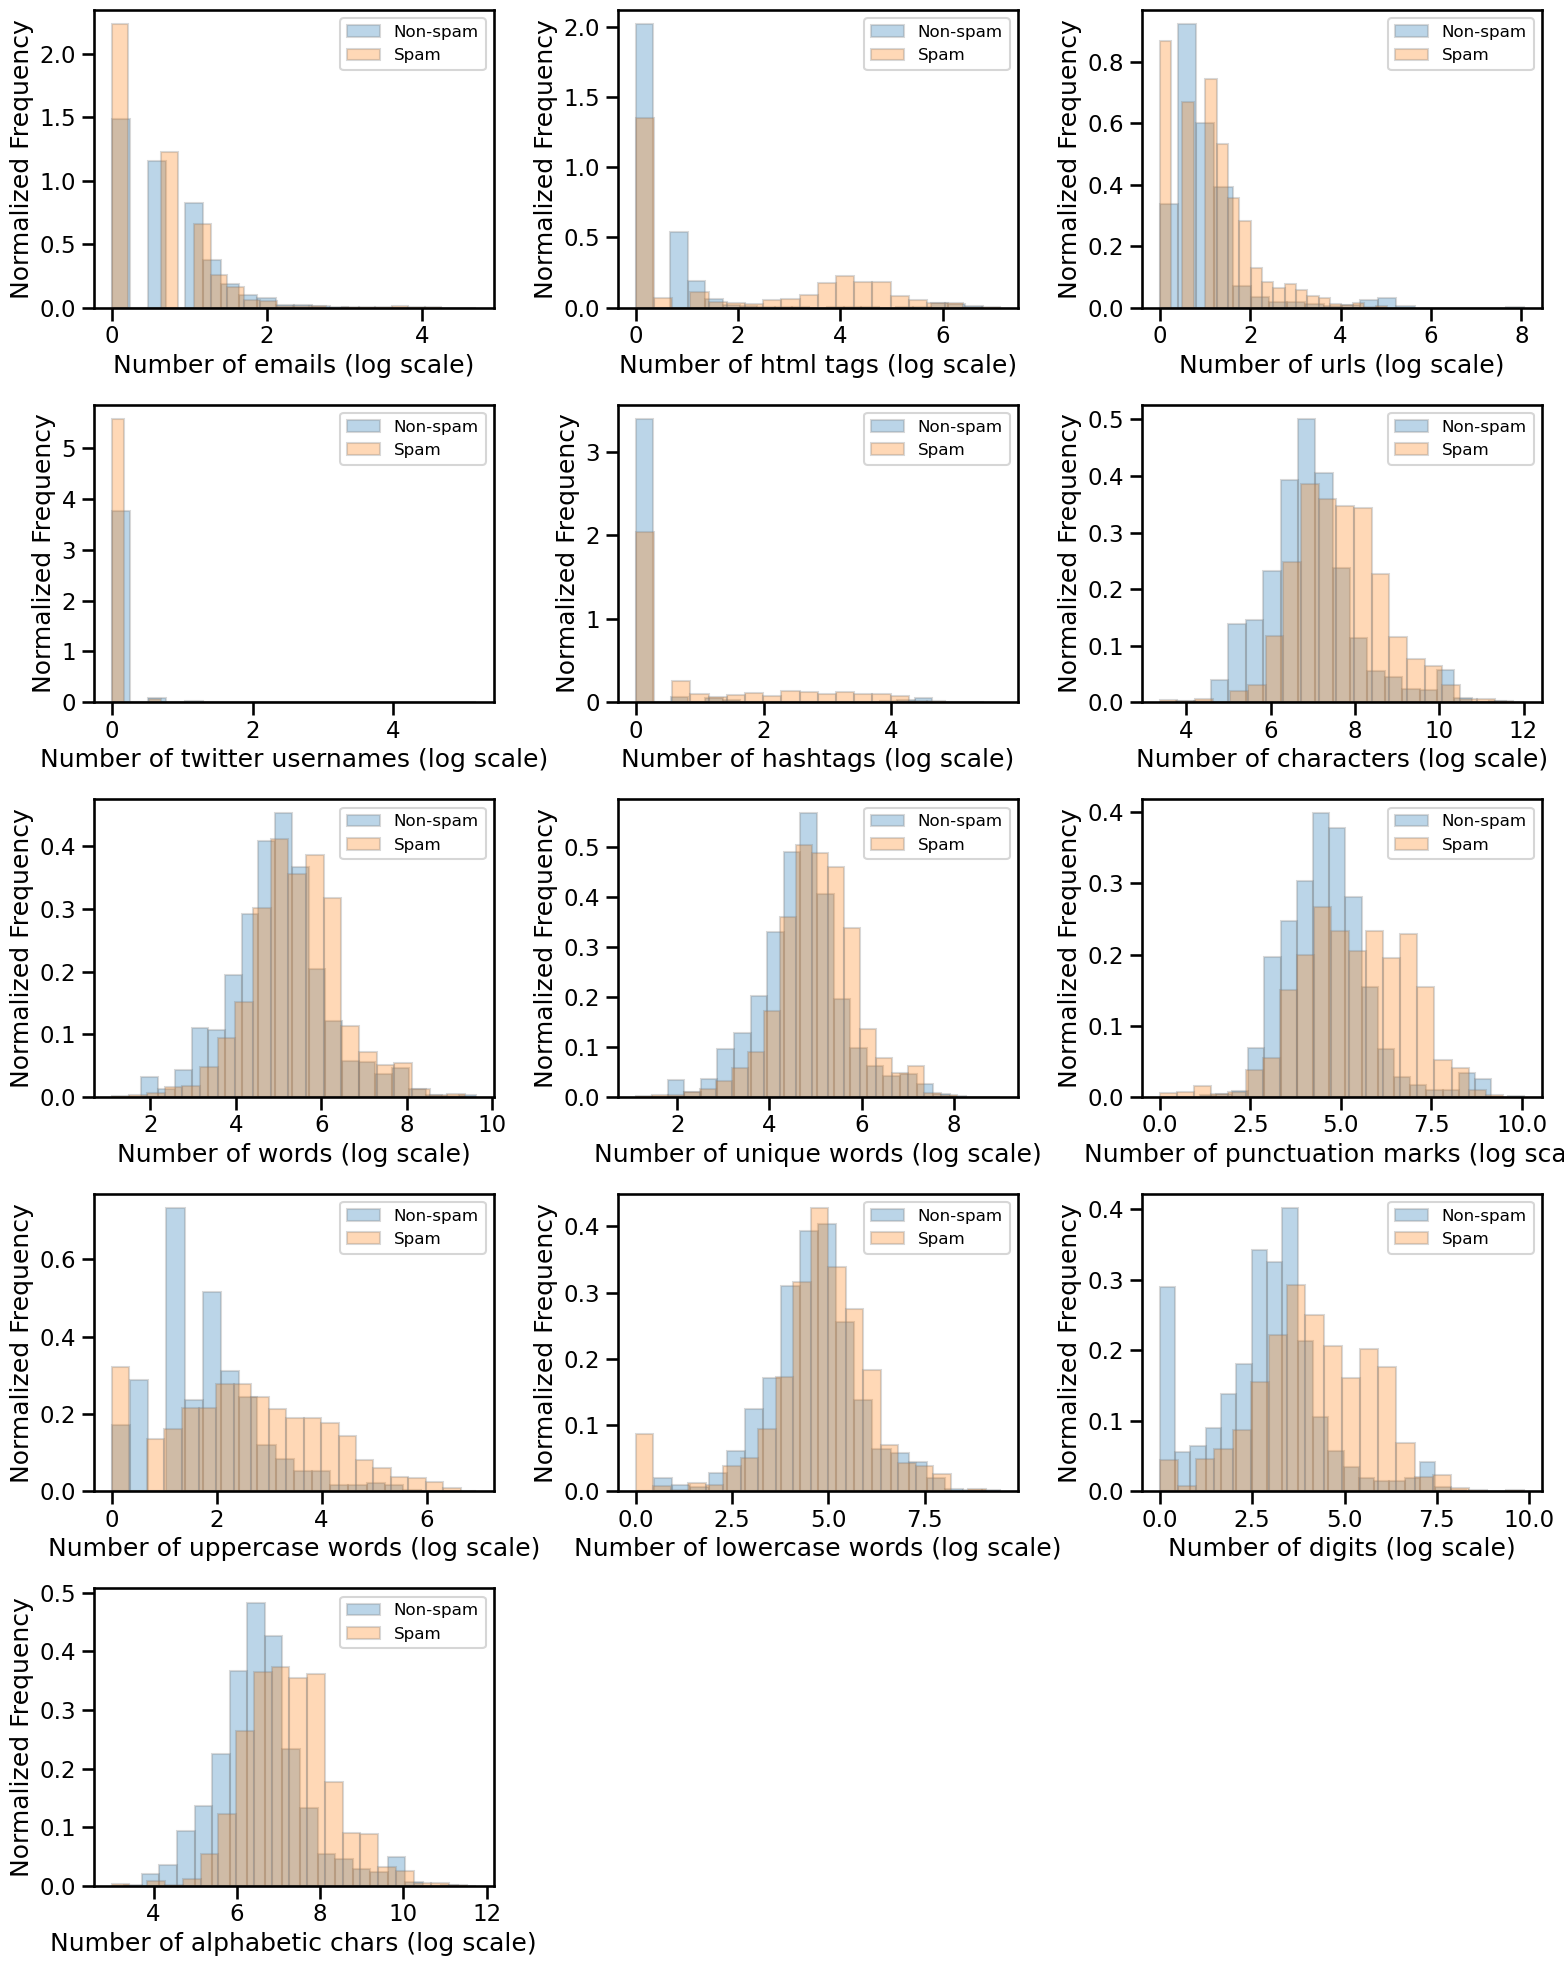

In [9]:
features = tools.get_features(df=df)

## Feature engineering :: Extracting features from text

Computers don't understand natural language. So, how do we represent text?

One of the simplest but effective and commonly used models to represent text for machine learning is the ***Bag of Words*** model ([online documentation](https://en.wikipedia.org/wiki/Bag-of-words_model)). When using this model, we discard most of the structure of the input text (word order, chapters, paragraphs, sentences and formating) and only count how often each word appears in each text. Discarding the structure and counting only word occurencies leads to the mental image of representing text as a "bag".  

**Example:** Let our toy corpus contain four documents.

$ corpus = ['I\;enjoy\;paragliding.',  $  
$\hspace{2cm}'I\;like\;NLP.',$  
$\hspace{2cm}'I\;like\;deep\;learning.',$  
$\hspace{2cm}'O\;Captain!\;my\;Captain!']$ 

In [10]:
tools.show_bag_of_words_vector()

,captain,deep,enjoy,i,learning,like,my,nlp,o,paragliding
Text,,,,,,,,,,
I enjoy paragliding.,0,0,1,1,0,0,0,0,0,1
I like NLP.,0,0,0,1,0,1,0,1,0,0
I like deep learning.,0,1,0,1,1,1,0,0,0,0
O Captain! my Captain!,2,0,0,0,0,0,1,0,1,0


Bag of Words has converted all documents into numeric vectors. Each column represents a word from the corpus and each row one of the four documents. The value in each cell represents the number of times that word appears in a specific document. For example, the fourth document has the word `captain` occuring twice and the words `my` and `O` occuring once.

## Build a spam detector

In the previous section, we saw how to perform text preprocessing and feature extraction from text. We are now ready to build our machine learning model for detecting spams. We will use a Logistic Regression classifier ([online documentation](https://en.wikipedia.org/wiki/Logistic_regression)).

First, split the data into two sets: the `train` set and the `test` set. We will then use the train set to `fit` our model. We will use 5-fold cross-validation. So the validation sets are automatically created internally. The test set will be used to `evaluate` the performance of our model. 

### Baseline

70.3% of samples are non-spam. This naive baseline model would reach 70+% for doing very little.

### Spam classification

<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

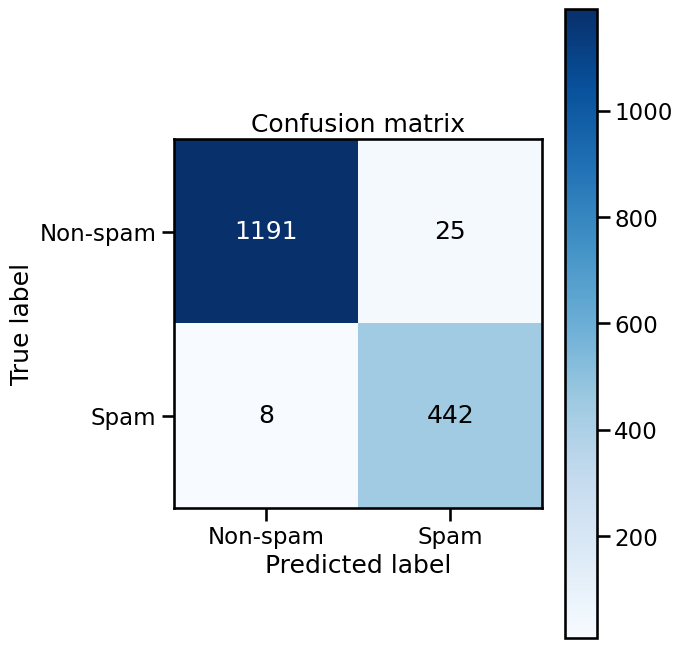

In [11]:
# Train/test splitting
df_train, df_test = tools.train_test_split_(df)

# Fit model on the train data
model = tools.fit_model(df_train)

# Print predictions on test set
tools.plot_confusion_matrix(df_test, model)

**Confusion matrices**  

Confusion matrices are a nice way of evaluating the performance of models for classification models. Rows correspond to the true classes and the columns to the predicted classes. Entries on the main diagonal of the confusion matrix correspond to correct predictions while the other cells tell us how many mistakes made our model ([online documentation]((https://en.wikipedia.org/wiki/Confusion_matrix))).

* The first row represents non-spam mails: 1'187 were correctly classified as 'non-spam', while 29 (~2,3%) were misclassified as 'spam'.
* The second row represents spam mails: 437 were correctly classified as 'spam', while 13 (~2,8%) were misclassified as 'non-spam'.

Our model did quite well!

### What did our model learn from the data?

Our logistic regression model has learned which words are the most indicative of non-spam and which words are the most indicative of spam. The positive coefficients on the right correspond to words that, according to the model, are indicative of spam. The negative coefficients on the left correspond to words that, according to the model, are indicative of non-spam.

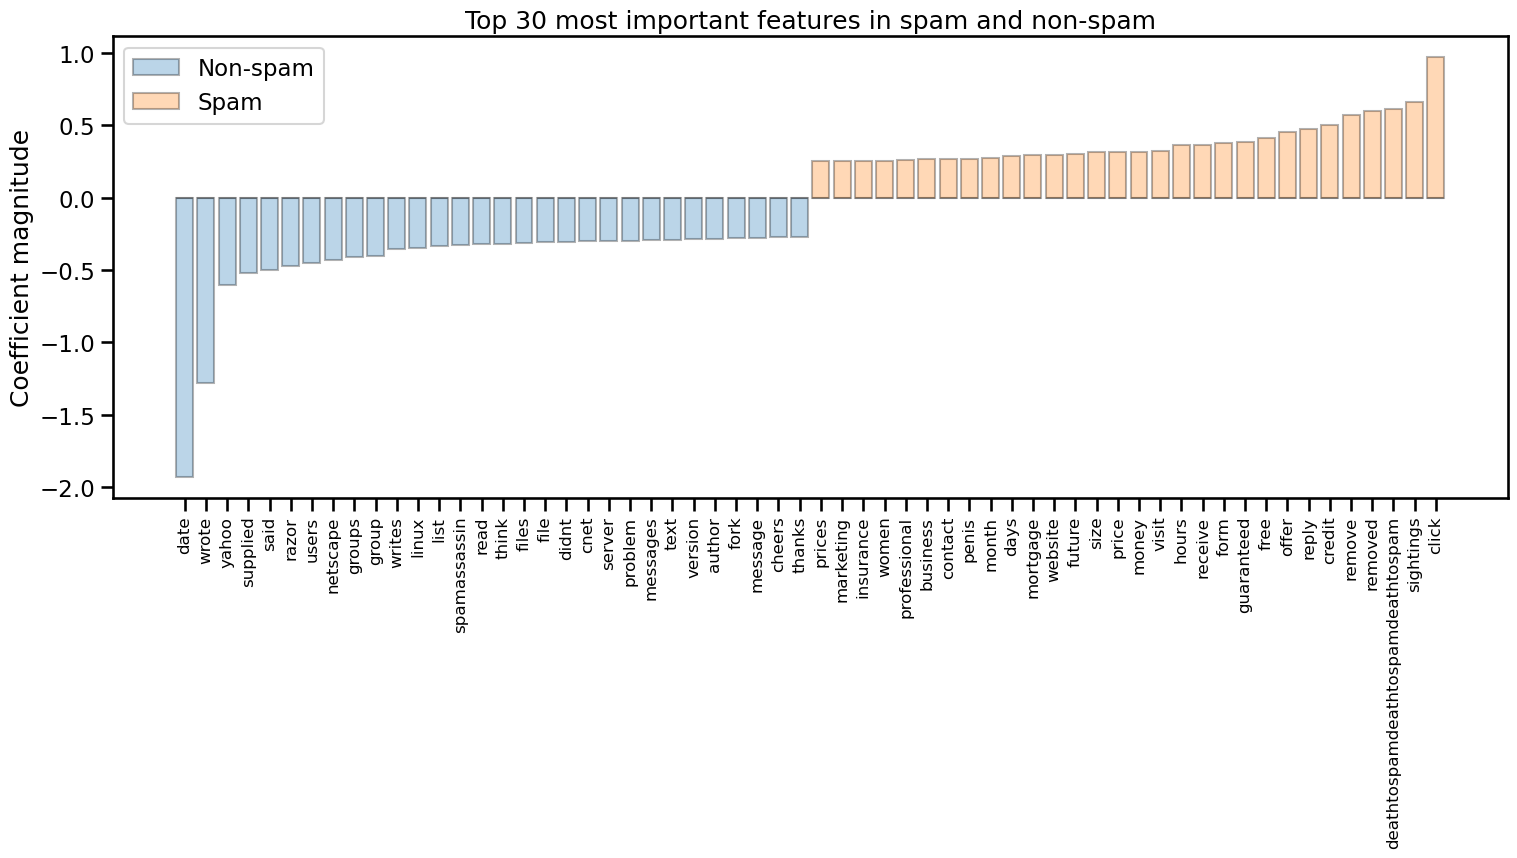

In [12]:
tools.visualize_coefficients(model, n_top_features=30)

<div class="alert alert-success">
<h3>Questions</h3>
    
__Q1.__ According to the model which words are strong indicators of non-spam, respectively spam? 
    
__Q2.__ Do they overlap with the results of our analysis?<br>
    
</div>

### Answers

__Q1.__ According to the model, words such as "date", "wrote", "yahoo", "said", "linux", "author", ... are strong indicators of non-spam.  

Words such as "click", "credit", "remove", "free", "offer", "money" ... indicate spam.

__Q2.__ Indeed some do. For example we had identified "wrote", "said" and "linux" as potential indicators of non-spam ealier. Similarly "click", "credit", "free", and "money" suggested spam.

### Error analysis :: Where does our model fail?

We will now analyze the misclassified mails in order to get some insights on where the model failed to make correct predictions. The *error_analysis* function below will show us the top features responsible for the model making a decision of prediction whether the mail is spam or non-spam.

Document index: 16 


Original Text
Dear Reader, How has Veuve Clicquot's sponsorship become so successful? Naomi Hancock,= =20 UK PR
Manager, tells us all about it in an exclusive interview. Also read= =20 about the launch of
SponsorRating, the first sponsorship rating agency,=20 our unsual transactions of the month, and a
"special X-treme" Sponsorship= =20 Alert. As this is the last issue for the summer, we wish you a
good August and=20 will be back in September. Your comments are always welcome, so please email us
at=20 news@sponsorclick.com. All our best, Rachael Mark Editor In this issue: 1. Sponsorship, How
and Why? Veuve Clicquot Speaks=20 2. Press Release: SponsorClick Launches the First Sponsorship
Ratin= g=20 Agency 3. Unusual Transactions of the Month 4. Sponsorship Alert Special X-treme 5.
Special Offers: Taylor Nelson Sofr=E8s, BVA, Sport+Markt,=20 Mediametrie, and more 6. More Matching
Opportunities With SponsorClick 7. How to Contact SponsorClick? =20 =20
---------------

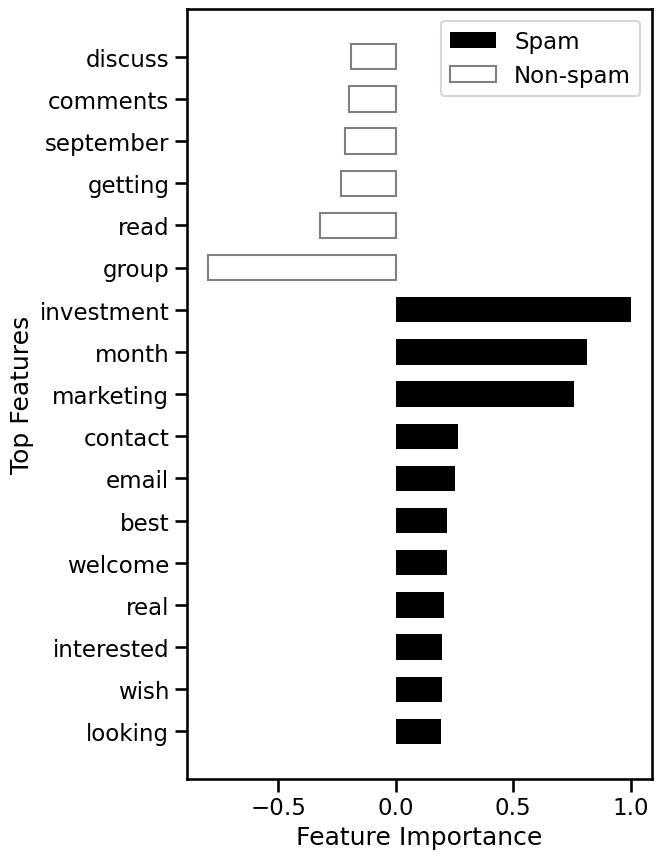

In [13]:
tools.error_analysis(df_test, model, doc_nbr=16)

<div class="alert alert-success">
<h3>Task 2</h3>
    
Let's change the `doc_nbr`.
</div>